#### Differencing

It refers to the technique of substracting a current value from the previous value.

It is used to convert a time series data from non-stationary to stationary.


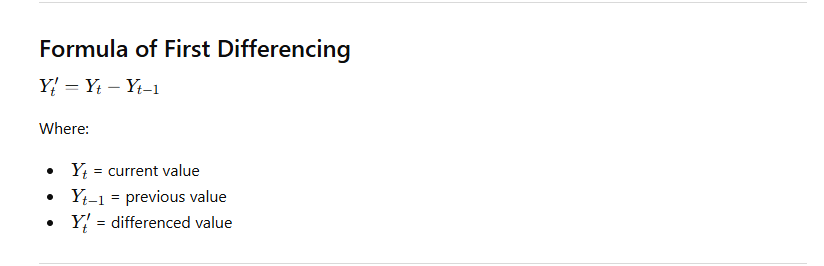


#### Why differencing is important ?

Ans  (i.)   Differencing is used to convert the non-stationary time series into stationary time series

     (ii.)  It is used to make the trends constant throughout the period of time.

     (iii.) It is used to make the mean   constant throughout the period of time

     (iv.)  It is used to make the standard deviation throughout the period of time.


#### Problem Statement :------------

1.  Perform differencing operation on the Airline Passengers dataset to convert the non stationary time series to stationary time series.


#### Step 1: Import all the necessary libraries

In [1]:
import  numpy                       as      np
import  pandas                      as      pd
import  matplotlib.pyplot           as      plt
import  seaborn                     as      sns

from    statsmodels.tsa.stattools   import  adfuller

#### Step 2:    Load the dataset

In [2]:
df = pd.read_csv("AirPassengers.csv")

In [3]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above dataset represents the passengers data for the starting date of each month starting from 1949 till 1960.

#### Step 3: Perform Data Exploration

In [4]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [5]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [6]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [7]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [8]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### OBSERVATIONS:

1.  The date column is string in nature.

2.  The value is integer in nature.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [9]:
#### Convert the datatype of date value to datetime

df['date'] = pd.to_datetime(df['date'])

In [10]:
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [11]:
#### get the length of the dataset

print('Length of the dataset is:', len(df))

Length of the dataset is: 144


In [12]:
#### get the shape of the dataset

print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (144, 2)


In [13]:
#### again get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The date column has been converted from object to datetime type.

In [14]:
#### Set the date column as an index

df.set_index('date',inplace=True)

In [15]:
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


#### OBSERVATIONS:

1.  The date column has been made as an index.

In [16]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [17]:
#### Rename the column "value" to "Passengers" in dataset

df.rename(columns={'value':'Passengers'},inplace=True)

In [18]:
df

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passengers' in the dataset.

#### Step 5: Plot the Time series data

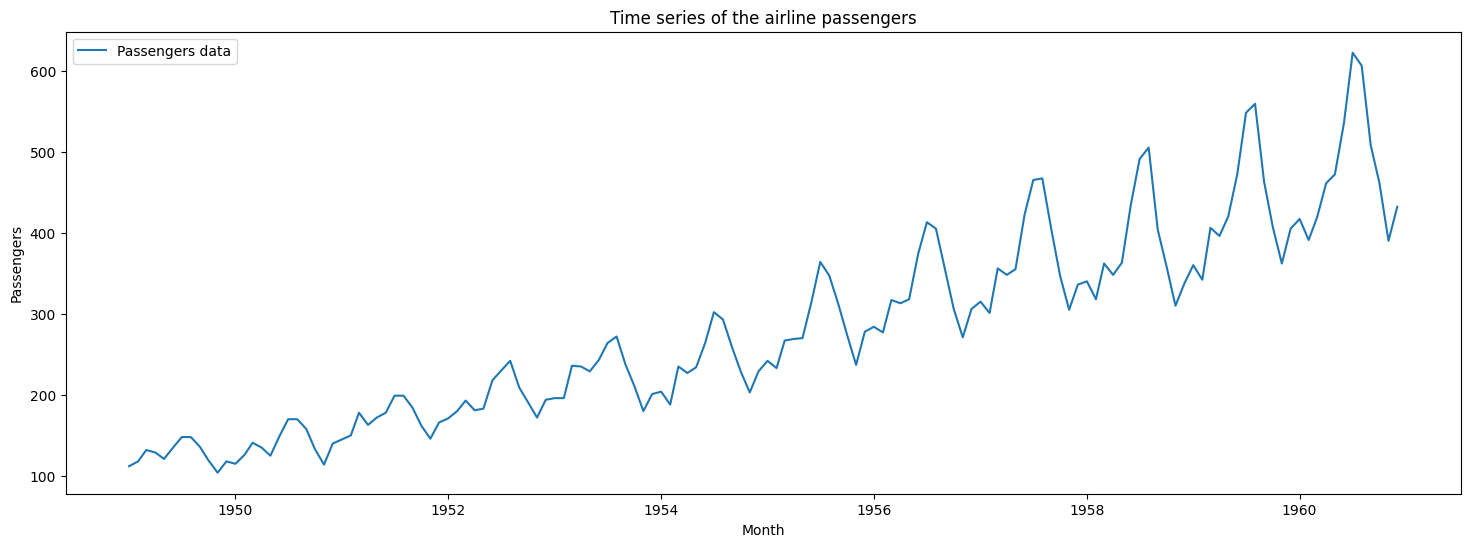

In [19]:
plt.figure(figsize=(18,6))

#### perform the plotting for the original time series
plt.plot(df.index, df['Passengers'], label = 'Passengers data')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the passengers data for the starting date of every month starting from 1944 till 1960.

2.  This graph represents the upward trend every year. This is because
    (a.)    With the increase in the number of years, the passengers also increase.

3.  As the trend shows an upward direction every year and is not constant over a period of time, so the time series data is non-stationary .

#### Step 6: Check the Stationarity of the time series data

In [20]:
from statsmodels.tsa.stattools  import  adfuller


#### perform adfuller test on the Passengers dataset

res = adfuller(df['Passengers'])

print(res)

(np.float64(0.8153688792060482), np.float64(0.991880243437641), 13, 130, {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}, np.float64(996.692930839019))


In [21]:
#### Print the details of adfuller

print('Test Statistics is:', res[0])    ####### measures the stationarity strength

print('P Value is:', res[1])            ####### measures ehether the time series is stationary or not

print('Lag Value is:', res[2])          ####### determines the number of lag observations

print('Number of Observations is:', res[3])  ######### determines the number of total observations

print('Critical values are:')            ####### determines the critical values used

for key,value in res[4].items():
    print(key,":",value)

Test Statistics is: 0.8153688792060482
P Value is: 0.991880243437641
Lag Value is: 13
Number of Observations is: 130
Critical values are:
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


#### OBSERVATIONS:

1.  P Value = 0.99

2.  As the P Value > 0.05 ================> Time series is said to be non stationary time series.

#### CONCLUSIONS:

1.  The above time series data is non stationary in nature.

#### Step 7: Apply First Differencing

In [22]:
#### Apply first differencing on the Passengers column

df_diff = df['Passengers'].diff()

In [23]:
df_diff

date
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: Passengers, Length: 144, dtype: float64

#### OBSERVATIONS:

1.  First Order Differencing is applied on the Passengers column.

2.  This is done to convert the non stationary time series to stationary time series.

#### Step 8: Remove all the NULL Values in the First Differencing

In [24]:
#### Remove all the NULL Values from the first differencing

df_diff = df_diff.dropna()

In [25]:
df_diff

date
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: Passengers, Length: 143, dtype: float64

#### OBSERVATIONS:

1.  It removes all the NULL Values from the dataset.

#### Step 9: Again perform data exploartion on the revised dataset

In [26]:
#### get the length of the dataset

print('Length of the dataset is:', len(df_diff))

Length of the dataset is: 143


In [27]:
#### get the shape of the dataset

print('Shape of the dataset is:', df_diff.shape)

Shape of the dataset is: (143,)


In [28]:
#### again get the information about the columns in the dataset

df_diff.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 143 entries, 1949-02-01 to 1960-12-01
Series name: Passengers
Non-Null Count  Dtype  
--------------  -----  
143 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


#### Step 10: Plot the time series data with first order of differencing

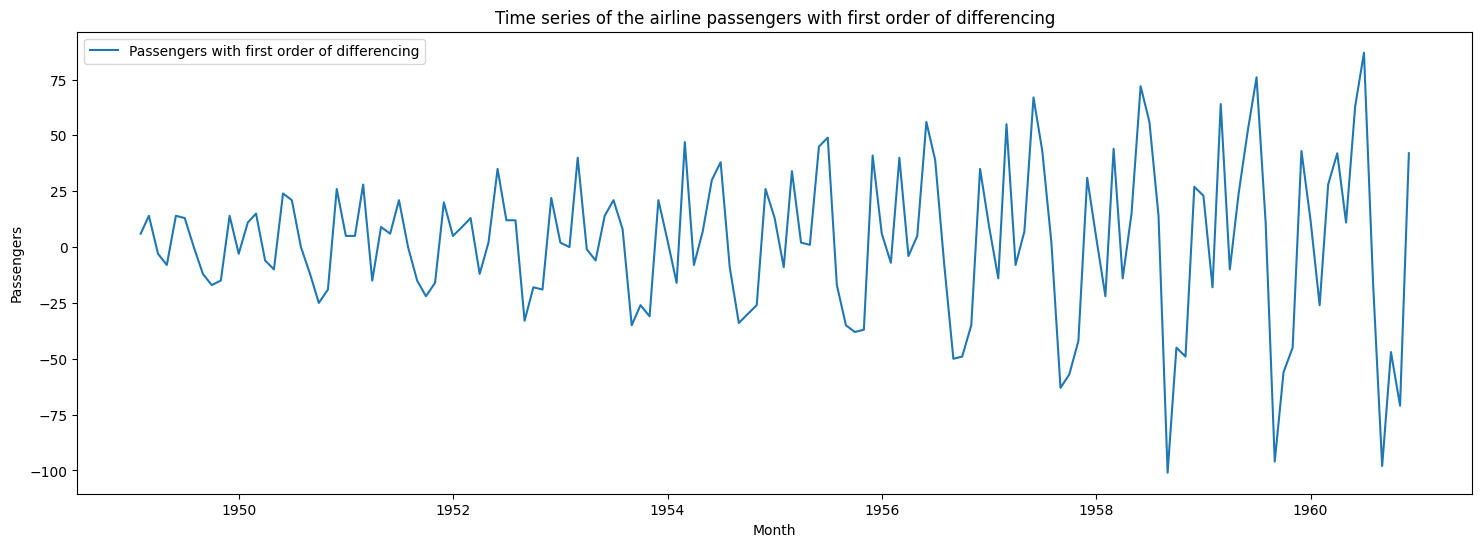

In [29]:
plt.figure(figsize=(18,6))

#### perform the plotting for the original time series
plt.plot(df_diff, label = 'Passengers with first order of differencing')

#### give the title of the graph
plt.title('Time series of the airline passengers with first order of differencing')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data starting from the first day for each month from 1944 till 1960.

2.  First Order of differencing is performed on the Passengers dataset.

3.  Then the time series analysis is performed on the revised dataset where we can see that the trend of the graph has reduced significantly and instead of showing any upward trend like the previous, the trend is showing consistency over a period of time.

4.  The mean and standard deviation of the model has become significantly stable over a period of time.

5.  So by performing the first order of differencing, the stationarity of the time series model has changed from non stationary to stationary.

#### Step 11: Apply ADF Testing 

In [30]:
from statsmodels.tsa.stattools import adfuller

#### Apply adfuller on the revised dataset

res = adfuller(df_diff)

print(res)

(np.float64(-2.8292668241699994), np.float64(0.0542132902838255), 12, 130, {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}, np.float64(988.5069317854084))


In [31]:
#### Print the details of adfuller

print('Test Statistics is:', res[0])    ####### measures the stationarity strength

print('P Value is:', res[1])            ####### measures ehether the time series is stationary or not

print('Lag Value is:', res[2])          ####### determines the number of lag observations

print('Number of Observations is:', res[3])  ######### determines the number of total observations

print('Critical values are:')            ####### determines the critical values used

for key,value in res[4].items():
    print(key,":",value)

Test Statistics is: -2.8292668241699994
P Value is: 0.0542132902838255
Lag Value is: 12
Number of Observations is: 130
Critical values are:
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


#### OBSERVATIONS:

1.  P-Value = 0.05 == 0.05.

2.  As P-Value <= 0.05, so the time series data is stationary.